In [1]:
from analytical import *
from electronic import *
from engine import *
from integrator import *
from selector import *
from trajectory import *
from path_sampling import *
import numpy as np
from matplotlib import pyplot as plt
import pickle

In [2]:
cranberry   = "#E69F00"
golden      = "#7CB342"
oxford_blue  = "#1C8DC1"

palette = [cranberry, golden, oxford_blue]

In [3]:
# Define the basin states

bound_A = -0.8
bound_B = 0.8

def in_stateA(q, s):
    return q<bound_A and s == 0

def in_stateB(q, s):
    return q>bound_B and s == 0

In [4]:
# Analytical model for plotting

def get_energies(x):
    H_dia = np.zeros((2,2))
    H_dia[0,0] = 0.5*0.1*np.power(x-1, 2)
    H_dia[1,1] = 0.5*0.1*np.power(x+1, 2)
    H_dia[1,0] = 0.2*0.05
    H_dia[0,1] = H_dia[1,0]

    eval, evec = np.linalg.eigh(H_dia)
    return H_dia[0,0], H_dia[1,1], eval.min(), eval.max()

x = np.linspace(-3, +3, 300)
energies = np.array([get_energies(xi) for xi in x])

In [5]:
# Generate seed trajectory for TPS
# Keep this block unchanged for exactly reproducible data!
# Conditions:
# --- Model ---
# eps = 0.05
# Vc = 0.2
# --- Seed trajectories ---
# v_init = -0.0087
# q_init = 1.0
# coeff_init = np.array([1.0, 0.0], dtype=complex)
# mass = 1836.15
# act_state_init = 0
# dt = 5
# max_steps = 10000000
# --- TPS setup ---
# TPS temperature = 12000K
# Sample size = 10000
# maximum trajectory length = 5000

v_init = -0.0087
q_init = 1.0
coeff_init = np.array([1.0, 0.0], dtype=complex)
mass = 1836.15
act_state_init = 0
dt = 5
max_steps = 10000000

x0 = 1.0
k = 0.1
Vc = 0.2
eps = 0.05

SHO_H = DoubleHarmonic(k=2 * eps, x0=1.0, vc=Vc * eps)
C_init = SHO_H.eigvecs(q_init)

initial_snapshot = Snapshot(positions=q_init,
                            velocities=v_init,
                            coefficients=coeff_init,
                            active_state=act_state_init,
                            gauge=C_init,
                            mass=mass,
                            is_grid=True)

seedMASH = MASHEngine(model=SHO_H, dt=dt, initial_snapshot=initial_snapshot)

seed_traj = seedMASH.propagate_until_X(max_steps=max_steps, stateA=in_stateA, stateB=in_stateB)

# --- Positions ---
oscillator_positions = np.array([seed_traj[i].positions for i in range(len(seed_traj))])
active_states = np.array([seed_traj[i].active_state for i in range(len(seed_traj))])
ground_state_positions = np.copy(oscillator_positions)
ground_state_positions[active_states > 0] = np.nan
excited_state_positions = np.copy(oscillator_positions)
excited_state_positions[active_states != 1] = np.nan

# --- Coefficients ---
oscillator_coeffs = np.array([sz_from_coeff(seed_traj[i].coefficients) for i in range(len(seed_traj))])
ground_state_coeffs = np.copy(oscillator_coeffs)
ground_state_coeffs[active_states > 0] = np.nan
excited_state_coeffs = np.copy(oscillator_coeffs)
excited_state_coeffs[active_states != 1] = np.nan

In [ ]:
# Temperature 12000 K and 1000 K comparison, set Vc to be 0.2 eps
# Relavent figures: 2d, 2e, 3, S2
master_seed = 39402
ensemble_size = 10000
max_traj_length = 5000
max_lag = 100
engine_builder = MASHEngine
T_12000 = 12000
T_1000 = 1000

tps_selector_12000 = UniformShootingSelector(temp=T_12000, mass=mass, stateA_func=in_stateA, stateB_func=in_stateB, alpha=0.9, seed=master_seed)
path_sampling_12000 = PathSampling(selector=tps_selector_12000, seed_traj=seed_traj, max_iter=ensemble_size,
                             max_length=max_traj_length, in_stateA=in_stateA, in_stateB=in_stateB)
tps_ensemble_12000, naive_tps_ensemble_12000 = path_sampling_12000.run(engine=engine_builder, model=SHO_H, dt=dt)
MC_rate_12000 = path_sampling_12000.MC_acceptance()
transit_times_12000, mean_time_12000, std_time_12000 = path_sampling_12000.transit_time_statistics(tps_ensemble=tps_ensemble_12000, dt=dt)
speedup_12000 = path_sampling_12000.efficiency_statistics(naive_tps_ensemble=naive_tps_ensemble_12000, mc_rate=MC_rate_12000)
ac_12000 = path_sampling_12000.compute_autocorrelation(data=transit_times_12000, max_lag=max_lag)
mean_hops_12000, std_hops_12000, q_hops_12000, phi_hops_12000 = path_sampling_12000.hop_statistics(tps_ensemble=tps_ensemble_12000)


tps_selector_1000 = UniformShootingSelector(temp=T_1000, mass=mass, stateA_func=in_stateA, stateB_func=in_stateB, alpha=0.9, seed=master_seed)
path_sampling_1000 = PathSampling(selector=tps_selector_1000, seed_traj=seed_traj, max_iter=ensemble_size,
                                  max_length=max_traj_length, in_stateA=in_stateA, in_stateB=in_stateB)
tps_ensemble_1000, naive_tps_ensemble_1000 = path_sampling_1000.run(engine=engine_builder, model=SHO_H, dt=dt)
MC_rate_1000 = path_sampling_1000.MC_acceptance()
transit_times_1000, mean_time_1000, std_time_1000 = path_sampling_1000.transit_time_statistics(tps_ensemble=tps_ensemble_1000, dt=dt)
speedup_1000 = path_sampling_1000.efficiency_statistics(naive_tps_ensemble=naive_tps_ensemble_1000, mc_rate=MC_rate_1000)
ac_1000 = path_sampling_1000.compute_autocorrelation(data=transit_times_1000, max_lag=max_lag)
mean_hops_1000, std_hops_1000, q_hops_1000, phi_hops_1000 = path_sampling_1000.hop_statistics(tps_ensemble=tps_ensemble_1000)

with open('brute_essential.pkl', 'rb') as f:
    brute_data = pickle.load(f)

transit_brute = brute_data[0]
mean_brute = brute_data[1]

--- TPS Iteration 0 ---
Accepted
--- TPS Iteration 1 ---
Accepted
--- TPS Iteration 2 ---
Accepted
--- TPS Iteration 3 ---
Accepted
--- TPS Iteration 4 ---
Rejected
--- TPS Iteration 5 ---
Rejected
--- TPS Iteration 6 ---
Accepted
--- TPS Iteration 7 ---
Accepted
--- TPS Iteration 8 ---
Accepted
--- TPS Iteration 9 ---
Accepted
--- TPS Iteration 10 ---
Accepted
--- TPS Iteration 11 ---
Rejected
--- TPS Iteration 12 ---
Rejected
--- TPS Iteration 13 ---
Rejected
--- TPS Iteration 14 ---
Accepted
--- TPS Iteration 15 ---
Accepted
--- TPS Iteration 16 ---
Rejected
--- TPS Iteration 17 ---
Accepted
--- TPS Iteration 18 ---
Rejected
--- TPS Iteration 19 ---
Rejected
--- TPS Iteration 20 ---
Rejected
--- TPS Iteration 21 ---
Accepted
--- TPS Iteration 22 ---
Accepted
--- TPS Iteration 23 ---
Accepted
--- TPS Iteration 24 ---
Accepted
--- TPS Iteration 25 ---
Rejected
--- TPS Iteration 26 ---
Rejected
--- TPS Iteration 27 ---
Rejected
--- TPS Iteration 28 ---
Rejected
--- TPS Iteration 29 ---

In [ ]:
# Figure 2
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D

unique_succession = []
for traj in tps_ensemble_12000:
    if not unique_succession or traj is not unique_succession[-1]:
        unique_succession.append(traj)

unique_succession = unique_succession[2460:2470]
consecutive_ensemble = unique_succession

plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
})

import matplotlib.pyplot as plt

fig = plt.figure(figsize=(11, 4.5), dpi=1200)

gs = fig.add_gridspec(
    nrows=3,
    ncols=2,
    width_ratios=[1.0, 1.45],
    height_ratios=[1, 1, 1],
    wspace=0.20,   # ⬅ increase horizontal spacing
    hspace=0.8    # ⬅ increase vertical spacing
)

# Left column: three stacked plots
ax3 = fig.add_subplot(gs[0, 0])     # plot 3
ax4 = fig.add_subplot(gs[1, 0])     # plot 4
ax5 = fig.add_subplot(gs[2, 0])     # plot 5

# Right column: top spans first two rows, bottom is third row
ax1 = fig.add_subplot(gs[0:2, 1])   # plot 1
ax2 = fig.add_subplot(gs[2, 1])     # plot 2

axes = [ax1, ax2, ax3, ax4, ax5]

###########################

color_ground = oxford_blue   
color_excited = cranberry  
color_diabatic = 'gray'

# Basin boundaries (assuming these are defined in your workspace)
bound_A = -0.8
bound_B = 0.8

# ==========================================
# PANEL (a): Analytical Potential
# ==========================================
x_pot = np.linspace(-3, +3, 300)
energies = np.array([get_energies(xi) for xi in x_pot])

# Shade basin regions under the ground-state curve
ground_curve = energies[:, 2]

left_mask = x_pot <= bound_A
right_mask = x_pot >= bound_B

ax3.fill_between(
    x_pot[left_mask], 0, ground_curve[left_mask],
    color='gray', alpha=0.15, zorder=1
)
ax3.fill_between(
    x_pot[right_mask], 0, ground_curve[right_mask],
    color='gray', alpha=0.15, zorder=1
)

ax3.plot(x_pot, energies[:,2], linewidth=1.5, color=color_ground, label="Ground", zorder=3)
ax3.plot(x_pot, energies[:,3], linewidth=1.5, color=color_excited, label="Excited", zorder=3)
ax3.plot(x_pot, energies[:,0], linestyle='--', color=color_diabatic, alpha=0.6, zorder=2)
ax3.plot(x_pot, energies[:,1], linestyle='--', color=color_diabatic, alpha=0.6, zorder=2)

ax3.set_xlim(-2.5, 2.5)
ax3.set_ylim(0.00, 0.2)
ax3.set_yticks([0, 0.1, 0.2])
ax3.set_xlabel(r"q / $a_0$")
ax3.set_ylabel("E / Ha")
ax3.hlines([0.04, 0.06], xmin=0, xmax=0.75, colors='gray', linestyles='--', linewidth=1.2)
ax3.text(0.8, 0.05, r"$g = 2V_c$", va='center')
ax3.text(-2.1, 0.03, "A",
         ha='center', va='center',
         fontsize=10, fontweight='bold', alpha=0.6)

ax3.text(2.2, 0.03, "B",
         ha='center', va='center',
         fontsize=10, fontweight='bold', alpha=0.6)

# ==========================================
# PANEL (b): Seed Trajectory Positions
# ==========================================
# Assuming seed_traj and dt are defined in your workspace
time_array = np.arange(len(seed_traj)) * dt

# Plot the trajectory
ax4.plot(time_array, -ground_state_positions, color=color_ground, linewidth=2, zorder=3)
ax4.plot(time_array, -excited_state_positions, color=color_excited, linewidth=2, zorder=3)

# Add shaded regions for Basin A and Basin B
ax4.axhspan(-2.5, bound_A, color='gray', alpha=0.15, zorder=1)
ax4.axhspan(bound_B, 2.5, color='gray', alpha=0.15, zorder=1)

# Direct text annotations instead of a legend
# Placed centrally in the x-axis, and vertically in the middle of the shaded regions
ax4.text(time_array[-1] / 2 +400, (bound_A - 2.5) / 2 +0.4, 'Basin A', 
        ha='left', va='center', fontsize=10, fontweight='bold', alpha=0.6)
ax4.text(time_array[-1] / 2 +400, (bound_B + 2.5) / 2 - 0.4, 'Basin B', 
        ha='left', va='center', fontsize=10, fontweight='bold', alpha=0.6)

ax4.set_xlabel("Time / a.u.")
ax4.set_ylabel(r"q / $a_0$")
ax4.set_yticks([-0.8,0,0.8])
ax4.set_xlim(0, time_array[-1])
ax4.set_ylim(-2.3, 2.3)

# ==========================================
# PANEL (c): Seed Trajectory Sz
# ==========================================

# Create a continuous Sz array to bridge the visual gaps
# This replaces NaN values in the ground array with the excited array values
continuous_Sz = np.copy(ground_state_coeffs)
mask = np.isnan(continuous_Sz)
if np.any(mask):
    continuous_Sz[mask] = excited_state_coeffs[mask]

# Plot the continuous line underneath to connect the hops
ax5.plot(time_array, continuous_Sz, color=oxford_blue, linewidth=2, alpha=1.0, zorder=1)

# Plot the colored state-dependent segments on top
ax5.plot(time_array, ground_state_coeffs, color=color_ground, linewidth=2, zorder=2)
ax5.plot(time_array, excited_state_coeffs, color=color_excited, linewidth=2, zorder=2)

ax5.axhline(y=0, linestyle="--", color='gray', alpha=0.6, zorder=0)

ax5.set_xlabel("Time / a.u.")
ax5.set_ylabel(r"$S_z$", labelpad=0)
ax5.set_xlim(0, time_array[-1])
ax5.set_ylim(-1.1, 1.1)

# ==========================================
# Universal Aesthetics & Export
# ==========================================
# panel_labels = ['a)', 'b)', 'c)']
# for i, ax in enumerate(axes):
#     ax.tick_params(direction='in', top=True, right=True)
#     ax.text(-0.15, 1., panel_labels[i], transform=ax.transAxes, 
#             fontsize=12, fontweight='bold', va='top', ha='right')

###########################


base_0 = mcolors.to_rgb(oxford_blue)
base_1 = mcolors.to_rgb(cranberry)

# ==========================================
# 2. TIME ANCHORING LOGIC (Untouched)
# ==========================================
time_shifts = [0.0] * len(consecutive_ensemble)
q_min, q_max = float('inf'), float('-inf')

for i in range(1, len(consecutive_ensemble)):
    grid_curr = [s for s in consecutive_ensemble[i] if s.is_grid]
    grid_prev = [s for s in consecutive_ensemble[i-1] if s.is_grid]
    shoot_idx_curr = next((idx for idx, s in enumerate(grid_curr) if getattr(s, 'shooting', False)), None)
    
    if shoot_idx_curr is not None:
        q_shoot = grid_curr[shoot_idx_curr].positions
        distances = [abs(s.positions - q_shoot) for s in grid_prev]
        shoot_idx_prev = np.argmin(distances)
        time_shifts[i] = (shoot_idx_prev * dt + time_shifts[i-1]) - (shoot_idx_curr * dt)
    else:
        time_shifts[i] = time_shifts[i-1]

# ==========================================
# 3. PLOTTING THE LINEAGE TREE
# ==========================================
max_absolute_time = 0
N = len(consecutive_ensemble)

for i, traj in enumerate(consecutive_ensemble):
    grid_traj = [s for s in traj if s.is_grid]
    times = np.arange(len(grid_traj)) * dt + time_shifts[i]
    positions = [s.positions for s in grid_traj]
    states = [s.active_state for s in grid_traj]
    
    q_min, q_max = min(q_min, min(positions)), max(q_max, max(positions))
    max_absolute_time = max(max_absolute_time, max(times))

    # Scale down linewidths for print resolution (0.8 to 2.5)
    lw = 0.8 + 1.7 * (i / (N - 1 if N > 1 else 1))**1.5 
    alpha = 0.25 + 0.75 * (i / (N - 1 if N > 1 else 1))
    if N == 1:
        lw = 2.5
        alpha = 1.0
    
    points = np.array([times, positions]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    colors = [base_0 if state == 0 else base_1 for state in states[:-1]]
    
    lc = LineCollection(segments, colors=colors, alpha=alpha, linewidths=lw)
    ax1.add_collection(lc)
    
    # Shooting nodes: scaled down to size 40, colored golden

    for j, snap in enumerate(grid_traj):
        if getattr(snap, 'shooting', False) is True:
                if i == 0:
                    continue
                ax1.scatter(times[j], positions[j], color=golden, 
                        edgecolor='white', marker='o', s=30, zorder=10, linewidth=0.8)

# ==========================================
# 4. BASIN BOUNDARIES & AESTHETICS
# ==========================================
ax1.axhline(y=-0.8, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
ax1.axhline(y=0.8, color='black', linestyle='--', linewidth=1.5, alpha=0.6)

# Faint shading for the stable basins
ax1.fill_between([min(time_shifts)-50, max_absolute_time+150], -2.5, -0.8, color='gray', alpha=0.08, zorder=0)
ax1.fill_between([min(time_shifts)-50, max_absolute_time+150], 0.8, 2.5, color='gray', alpha=0.08, zorder=0)

# Journal-standard axis labels
ax1.set_xlabel("Anchored Time / a.u.", fontweight='medium')
ax1.set_ylabel("$q$ / a$_0$", fontweight='medium')

# Custom Legend
legend_elements = [
    Line2D([0], [0], color=oxford_blue, lw=3, label='Lower State'),
    Line2D([0], [0], color=cranberry, lw=3, label='Upper State'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=golden, 
            markeredgecolor='white', markersize=8, label='Shooting Node'),
    Line2D([0], [0], color='black', ls='--', lw=1.5, label='Basin Boundaries')
]
ax1.legend(handles=legend_elements, loc='upper left', bbox_to_anchor = (0.0,0.9), frameon=False, fontsize=9)

# Perfect framing
ax1.set_xlim(min(time_shifts) - 20, max_absolute_time + 100)
ax1.set_ylim(q_min - 0.2, q_max + 0.2)

# Thick boundaries and inward ticks
ax1.tick_params(direction='in', top=True, right=True)
for spine in ax1.spines.values():
    spine.set_linewidth(1.5)

# ==========================================
# 2. PLOTTING THE AUTOCORRELATION
# ==========================================
# Main decay line (Winter Pine)
# Adding white marker faces for that crisp, premium journal look
ax2.plot(range(100), ac_12000, color=golden, 
        linewidth=1.5, linestyle='-', marker='o', markersize=4, 
        markerfacecolor='white', markeredgewidth=1.0, zorder=3)

# y=0 baseline
ax2.axhline(0, color='black', linewidth=1.0, zorder=2)

# 1/e Threshold (Cranberry)
ax2.axhline(np.exp(-1), color='darkgray', linestyle='--', linewidth=1.5, zorder=4, 
            label=r'$1/e$ Threshold')

# ==========================================
# 3. LABELS & FORMATTING
# ==========================================
ax2.set_xlabel("Monte Carlo Step Lag $n$", fontweight='medium')
ax2.set_ylabel(r"$C(n)$", fontweight='medium')

# Grid and Ticks
ax2.tick_params(direction='in', top=True, right=True)
ax2.grid(True, linestyle=':', alpha=0.5, zorder=0)

# Thicken axes
for spine in ax2.spines.values():
    spine.set_linewidth(1.5)

# Frame the data perfectly
ax2.set_xlim(0, 100) # max_mc_lag
# Standard limits for normalized ACF to show the peak at 1.0 and a bit of negative space
ax2.set_ylim(0.2, 1.05)
ax2.set_yticks([0, 0.5, 1.0])

# Clean, borderless legend
ax2.legend(loc='upper right', frameon=False, fontsize=9)

ax1.text(-0.065, 1.0, r"$\mathbf{d)}$", transform=ax1.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
ax2.text(-0.065, 1.02, r"$\mathbf{e)}$", transform=ax2.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
ax3.text(-0.1, 1.05, r"$\mathbf{a)}$", transform=ax3.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
# ax4.text(-0.1, 1.05, r"$\mathbf{b)}$", transform=ax4.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
ax5.text(-0.1, 1.05, r"$\mathbf{c)}$", transform=ax5.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
ax1.set_yticks([-0.8, 0.0, 0.8])


# x = np.linspace(0, 10, 200)
# for i, ax in enumerate(axes, start=1):
#     ax.set_title(f"Plot {i}", fontsize=10)

plt.show()

In [ ]:
# Figure S2
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
})

fig, axs = plt.subplots(5, 2, figsize=(10, 10), dpi=1200)
panel_labels = [r'a)', r'b)', r'c)', r'd)', r'e)', r'f)', r'g)', r'h)', r'i)', r'j)']

for k in range(10):
    row = k // 2
    col = k % 2
    unique_succession = []
    for traj in tps_ensemble_12000:
        if not unique_succession or traj is not unique_succession[-1]:
            unique_succession.append(traj)

    unique_succession = unique_succession[2460:2461+k]
    consecutive_ensemble = unique_succession
    ax1 = axs[row, col]   # plot 1
    # ==========================================
    # 2. TIME ANCHORING LOGIC (Untouched)
    # ==========================================
    time_shifts = [0.0] * len(consecutive_ensemble)
    q_min, q_max = float('inf'), float('-inf')

    for i in range(1, len(consecutive_ensemble)):
        grid_curr = [s for s in consecutive_ensemble[i] if s.is_grid]
        grid_prev = [s for s in consecutive_ensemble[i-1] if s.is_grid]
        shoot_idx_curr = next((idx for idx, s in enumerate(grid_curr) if getattr(s, 'shooting', False)), None)
        
        if shoot_idx_curr is not None:
            q_shoot = grid_curr[shoot_idx_curr].positions
            distances = [abs(s.positions - q_shoot) for s in grid_prev]
            shoot_idx_prev = np.argmin(distances)
            time_shifts[i] = (shoot_idx_prev * dt + time_shifts[i-1]) - (shoot_idx_curr * dt)
        else:
            time_shifts[i] = time_shifts[i-1]

    # ==========================================
    # 3. PLOTTING THE LINEAGE TREE
    # ==========================================
    max_absolute_time = 0
    N = len(consecutive_ensemble)

    for i, traj in enumerate(consecutive_ensemble):
        grid_traj = [s for s in traj if s.is_grid]
        times = np.arange(len(grid_traj)) * dt + time_shifts[i]
        positions = [s.positions for s in grid_traj]
        states = [s.active_state for s in grid_traj]
        
        q_min, q_max = min(q_min, min(positions)), max(q_max, max(positions))
        max_absolute_time = max(max_absolute_time, max(times))

        # Scale down linewidths for print resolution (0.8 to 2.5)
        lw = 0.8 + 1.7 * (i / (N - 1 if N > 1 else 1))**1.5 
        alpha = 0.25 + 0.75 * (i / (N - 1 if N > 1 else 1))
        if N == 1:
            lw = 2.5
            alpha = 1.0
        
        points = np.array([times, positions]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        colors = [base_0 if state == 0 else base_1 for state in states[:-1]]
        
        lc = LineCollection(segments, colors=colors, alpha=alpha, linewidths=lw)
        ax1.add_collection(lc)
        
        # Shooting nodes: scaled down to size 40, colored golden

        for j, snap in enumerate(grid_traj):
            if getattr(snap, 'shooting', False) is True:
                    if i == 0:
                        continue
                    ax1.scatter(times[j], positions[j], color=golden, 
                            edgecolor='white', marker='o', s=30, zorder=10, linewidth=0.8)

    # ==========================================
    # 4. BASIN BOUNDARIES & AESTHETICS
    # ==========================================
    ax1.axhline(y=-0.8, color='black', linestyle='--', linewidth=1.5, alpha=0.6)
    ax1.axhline(y=0.8, color='black', linestyle='--', linewidth=1.5, alpha=0.6)

    # Faint shading for the stable basins
    ax1.fill_between([-600, 600], -2.5, -0.8, color='gray', alpha=0.08, zorder=0)
    ax1.fill_between([-600, 600], 0.8, 2.5, color='gray', alpha=0.08, zorder=0)

    # Journal-standard axis labels
    ax1.set_ylabel("$q$ / a$_0$", fontweight='medium')
    if k >= 8:
        ax1.tick_params(labelbottom=True, bottom=True)
        ax1.set_xlabel("Anchored Time / a.u.", fontweight='medium')
    else:
        ax1.tick_params(labelbottom=False, bottom=True)
        ax1.set_xlabel("")

    # Perfect framing
    ax1.set_xlim(min(time_shifts) - 20, max_absolute_time + 100)
    ax1.set_xlim([-400, 600])
    ax1.set_ylim(q_min - 0.2, q_max + 0.2)
    ax1.set_yticks([-0.8, 0, 0.8])

    # Thick boundaries and inward ticks
    ax1.tick_params(direction='in', top=True, right=True)
    for spine in ax1.spines.values():
        spine.set_linewidth(1.5)
    ax1.text(-0.08, 1.0, panel_labels[k], transform=ax1.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')


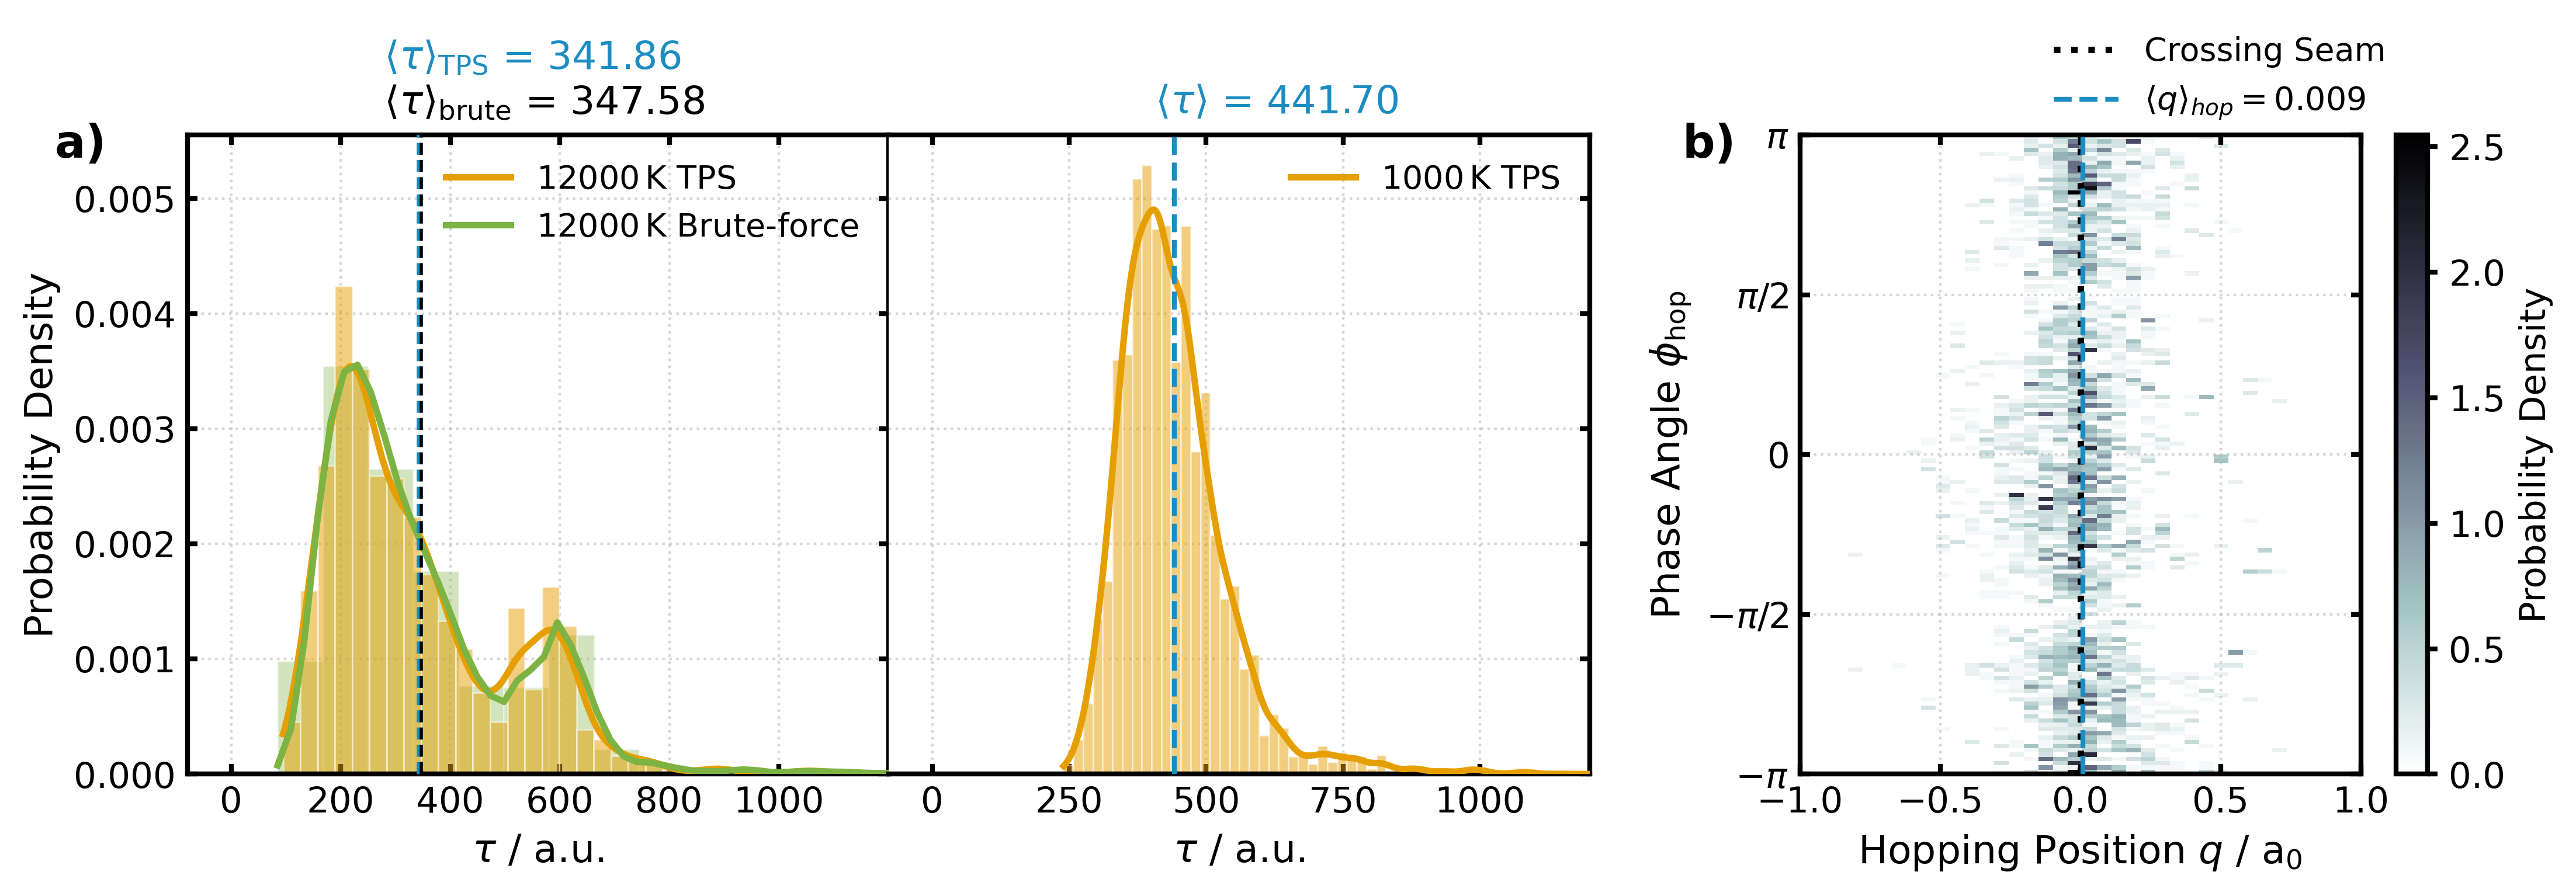

In [ ]:
# Figure 3
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from matplotlib.gridspec import GridSpec
import pickle

# -----------------------------
# Aesthetic setup
# -----------------------------
plt.rcParams.update({
    "font.size": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.linewidth": 1.5,
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "xtick.minor.width": 1.0,
    "ytick.minor.width": 1.0,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 2,
    "ytick.minor.size": 2,
})

# Your palette
oxford_blue = "#E69F00"
golden = "#7CB342"
cranberry = "#1C8DC1"

with open('Fig2_data.pkl', 'rb') as f:
    Fig2_data = pickle.load(f)



def plot_transit_time_compact_row(
    transit_times_12000,
    mean_12000,
    transit_times_brute,
    mean_brute,
    transit_times_1000,
    mean_1000,
    q_hops,
    angle_hops
):
    # Layout:
    # [ overlay(12000K + brute-force) ] [ 1000K ]   [ hopping distribution ]
    #
    # First two panels are clamped together with shared y
    # Third panel is independent and separated slightly

    fig = plt.figure(figsize=(11.0, 3.6), dpi=400)
    gs = GridSpec(
        1, 4,
        width_ratios=[1.0, 1.0, 0.30, 1.0],  # tiny spacer before panel 3
        wspace=0.0
    )

    ax1 = fig.add_subplot(gs[0, 0])              # overlay panel
    ax2 = fig.add_subplot(gs[0, 1], sharey=ax1) # 1000 K panel
    ax3 = fig.add_subplot(gs[0, 3])              # hopping panel

    # ==========================================
    # PANEL (a): overlay 12000K + brute-force
    # ==========================================
    ax1.hist(
        transit_times_12000,
        bins=60,
        density=True,
        color=oxford_blue,
        edgecolor="white",
        linewidth=0.5,
        alpha=0.50,
        zorder=2,
    )

    kde_12000 = gaussian_kde(transit_times_12000)
    x_grid_12000 = np.linspace(min(transit_times_12000), max(transit_times_12000), 500)
    ax1.plot(
    x_grid_12000,
    kde_12000(x_grid_12000),
    color=oxford_blue,
    linewidth=2,
    zorder=3,
    label=r"$12000\,\mathrm{K}$ TPS"
)

    ax1.axvline(
        mean_12000,
        color=cranberry,
        linestyle="--",
        linewidth=1.,
        zorder=4,
    )

    ax1.hist(
        transit_times_brute,
        bins=147,
        density=True,
        color=golden,
        edgecolor="white",
        linewidth=0.5,
        alpha=0.35,
        zorder=1,
    )

    kde_brute = gaussian_kde(transit_times_brute)
    x_grid_brute = np.linspace(min(transit_times_brute), max(transit_times_brute), 500)
    ax1.plot(
    x_grid_brute,
    kde_brute(x_grid_brute),
    color=golden,
    linewidth=2,
    zorder=3,
    label=r"$12000\,\mathrm{K}$ Brute-force"
)

    ax1.axvline(
        mean_brute,
        color="black",
        linestyle="--",
        linewidth=1.,
        zorder=4,
    )

    ax1.set_xlabel(r"$\tau$ / a.u.", fontweight="medium", fontsize=12)
    ax1.set_ylabel("Probability Density", fontweight="medium", fontsize=12)
    ax1.set_xticks([0,200,400,600,800,1000])
    ax1.set_xlim([-80, 1200])
    ax1.tick_params(direction="in", top=True, right=True)
    ax1.grid(True, linestyle=":", alpha=0.5, zorder=0)

    for spine in ax1.spines.values():
        spine.set_linewidth(1.5)

    ax1.text(
        -0.12, 0.95, r"$\mathbf{a)}$",
        transform=ax1.transAxes,
        fontsize=14,
        fontweight="bold",
        va="bottom",
        ha="right",
    )

    # ax1.text(
    #     0.50, 0.95,
    #     r"$12000\,\mathrm{K}$" + "\n" + "Brute-force",
    #     transform=ax1.transAxes,
    #     fontsize=10,
    #     fontweight="medium",
    #     va="top",
    #     ha="left",
    # )

    ax1.text(
        0.28, 1.15,
        rf"$\langle\tau\rangle_{{\mathrm{{TPS}}}}$ = {mean_12000:.2f}",
        transform=ax1.transAxes,
        fontsize=12,
        fontweight="medium",
        color=cranberry,
        va="top",
        ha="left",
    )

    ax1.text(
        0.28, 1.08,
        rf"$\langle\tau\rangle_{{\mathrm{{brute}}}}$ = {mean_brute:.2f}",
        transform=ax1.transAxes,
        fontsize=12,
        fontweight="medium",
        color="black",
        va="top",
        ha="left",
    )

    ax1.legend(
    loc="upper right",
    frameon=False,
    fontsize=10
)

    # ==========================================
    # PANEL (b): 1000 K
    # ==========================================
    ax2.hist(
        transit_times_1000,
        bins=60,
        density=True,
        color=oxford_blue,
        edgecolor="white",
        linewidth=0.5,
        alpha=0.50,
        zorder=2,
    )

    kde_1000 = gaussian_kde(transit_times_1000)
    x_grid_1000 = np.linspace(min(transit_times_1000), max(transit_times_1000), 500)
    ax2.plot(
    x_grid_1000,
    kde_1000(x_grid_1000),
    color=oxford_blue,
    linewidth=2,
    zorder=3,
    label=r"$1000\,\mathrm{K}$ TPS"
)

    ax2.axvline(
        mean_1000,
        color=cranberry,
        linestyle="--",
        linewidth=1.5,
        zorder=4,
    )

    ax2.set_xlabel(r"$\tau$ / a.u.", fontweight="medium", fontsize=12)
    ax2.set_xlim([-80, 1200])
    ax2.tick_params(direction="in", top=True, right=True)
    ax2.grid(True, linestyle=":", alpha=0.5, zorder=0)

    for spine in ax2.spines.values():
        spine.set_linewidth(1.5)

    # Make first two panels seamless
    ax2.tick_params(left=False, labelleft=False)
    ax2.spines["left"].set_visible(False)

    # ax2.text(
    #     -0.08, 0.95, "b)",
    #     transform=ax2.transAxes,
    #     fontsize=12,
    #     fontweight="bold",
    #     va="bottom",
    #     ha="right",
    # )

    # ax2.text(
    #     0.60, 0.95,
    #     r"$1000\,\mathrm{K}$",
    #     transform=ax2.transAxes,
    #     fontsize=10,
    #     fontweight="medium",
    #     va="top",
    #     ha="left",
    # )

    ax2.legend(
    loc="upper right",
    frameon=False,
    fontsize=10
)

    ax2.text(
        0.38, 1.08,
        rf"$\langle\tau\rangle$ = {mean_1000:.2f}",
        transform=ax2.transAxes,
        fontsize=12,
        fontweight="medium",
        color=cranberry,
        va="top",
        ha="left",
    )

    # Clamp top-row y scale
    y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
    ax1.set_ylim(0, y_max)
    ax2.set_ylim(0, y_max)

    # ==========================================
    # PANEL (c): hopping position vs phase angle
    # ==========================================

    cmap = plt.get_cmap("bone_r").copy()
    cmap.set_bad(cmap(0.0))  # empty bins use the 0-density color

    hist = ax3.hist2d(
        q_hops,
        angle_hops,
        bins=[30, 150],
        density=True,
        cmap=cmap,
    )

    cbar = fig.colorbar(hist[3], ax=ax3)
    cbar.set_label("Probability Density", fontweight="medium", fontsize=11)

    ax3.axvline(
        0.0,
        color="black",
        linestyle=":",
        linewidth=2.0,
        zorder=4,
        label="Crossing Seam",
    )

    mean_q = np.mean(q_hops)
    ax3.axvline(
        mean_q,
        color=cranberry,
        linestyle="--",
        linewidth=1.5,
        zorder=5,
        label=rf"$\langle q\rangle_{{hop}} = {mean_q:.3f}$",
    )

    ax3.set_xlabel(r"Hopping Position $q$ / a$_0$", fontweight="medium", fontsize=12)
    ax3.set_ylabel(r"Phase Angle $\phi_{\mathrm{hop}}$", fontweight="medium", fontsize=12)

    ax3.set_xticks([-1, -0.5, 0, 0.5, 1])
    ax3.set_yticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax3.set_yticklabels([r"$-\pi$", r"$-\pi/2$", r"$0$", r"$\pi/2$", r"$\pi$"])

    ax3.tick_params(direction="in", top=True, right=True)
    ax3.grid(True, linestyle=":", alpha=0.5, zorder=0)

    for spine in ax3.spines.values():
        spine.set_linewidth(1.5)

    ax3.legend(loc="upper left", bbox_to_anchor=(0.4, 1.2), frameon=False, fontsize=10)

    ax3.text(
        -0.12, 0.95, r"$\mathbf{b)}$",
        transform=ax3.transAxes,
        fontsize=14,
        fontweight="bold",
        va="bottom",
        ha="right",
)

    # Final layout
    fig.subplots_adjust(left=0.08, right=0.98, bottom=0.16, top=0.92)
    # plt.savefig("Transit_Time_Distributions_Combined.png", dpi=400, bbox_inches="tight")
    plt.show()


# Example usage:
plot_transit_time_compact_row(
    transit_times_12000=transit_times_12000,
    mean_12000=mean_time_12000,
    transit_times_brute=transit_brute,
    mean_brute=mean_brute,
    transit_times_1000=transit_times_1000,
    mean_1000=mean_time_1000,
    q_hops=q_hops_12000,
    angle_hops=phi_hops_12000
)

In [ ]:
# Temperature sweeping
# For reproduction: do not forget to generate the seed trajectory.

def remove_off_grid(traj):
    return Trajectory([snap for snap in traj if snap.is_grid])

master_seed = 39402

ensemble_size = [87000, 81000, 75000, 69000, 64000, 58000, 53000, 48000, 44000, 39000, 35000, 31000, 27000, 24000, 21000, 18000,
                 15000, 12000, 10000, 10000, 10000, 10000, 10000, 10000, 10000, 10000, 10000]
max_traj_length = 5000

temperature_sweep = np.concatenate((np.linspace(30000, 1000, 20), np.linspace(900, 300, 7)))

mean_hopful = []
mean_hopless = []
mean_total = []
mean_hop_list = []

current_seed = seed_traj

for temp_k in range(len(temperature_sweep)):
    temp = temperature_sweep[temp_k]
    ensem_size = ensemble_size[temp_k]
    
    tps_selector = UniformShootingSelector(temp=temp, mass=mass, stateA_func=in_stateA, stateB_func=in_stateB, alpha=0.9, seed=master_seed)
    path_sampling = PathSampling(selector=tps_selector, seed_traj=current_seed, max_iter=ensem_size,
                                max_length=max_traj_length, in_stateA=in_stateA, in_stateB=in_stateB)
    engine_builder = MASHEngine
    tps_ensemble, naive_tps_ensemble = path_sampling.run(engine=engine_builder, model=SHO_H, dt=dt)

    transit_times, mean_time, std_time = path_sampling.transit_time_statistics(tps_ensemble=tps_ensemble, dt=dt)
    mean_total.append(mean_time)
    mean_hops, std_hops, q_hops, phi_hops = path_sampling.hop_statistics(tps_ensemble=tps_ensemble)
    mean_hop_list.append(mean_hops)

    burn_in_frames = int(0.15 * len(tps_ensemble))
    trimmed_ensemble = tps_ensemble[burn_in_frames:]
    nohop_ensemble = [traj for traj in trimmed_ensemble if not any(snap.hop for snap in traj)]
    nohop_ensemble_no_offgrid = [remove_off_grid(traj) for traj in nohop_ensemble]
    TT_dist_nohop = [(len(traj)-1) * dt for traj in nohop_ensemble_no_offgrid]
    mean_hopless.append(np.mean(TT_dist_nohop))
    hop_ensemble = [traj for traj in trimmed_ensemble if any(snap.hop for snap in traj)]
    if len(hop_ensemble) > 50:
        hop_ensemble_no_offgrid = [remove_off_grid(traj) for traj in hop_ensemble]
        TT_dist_hop = [(len(traj)-1) * dt for traj in hop_ensemble_no_offgrid]
        mean_hopful.append(np.mean(TT_dist_hop))
            
    else:
        mean_hopful.append(np.nan)
    current_seed = tps_ensemble[-1]

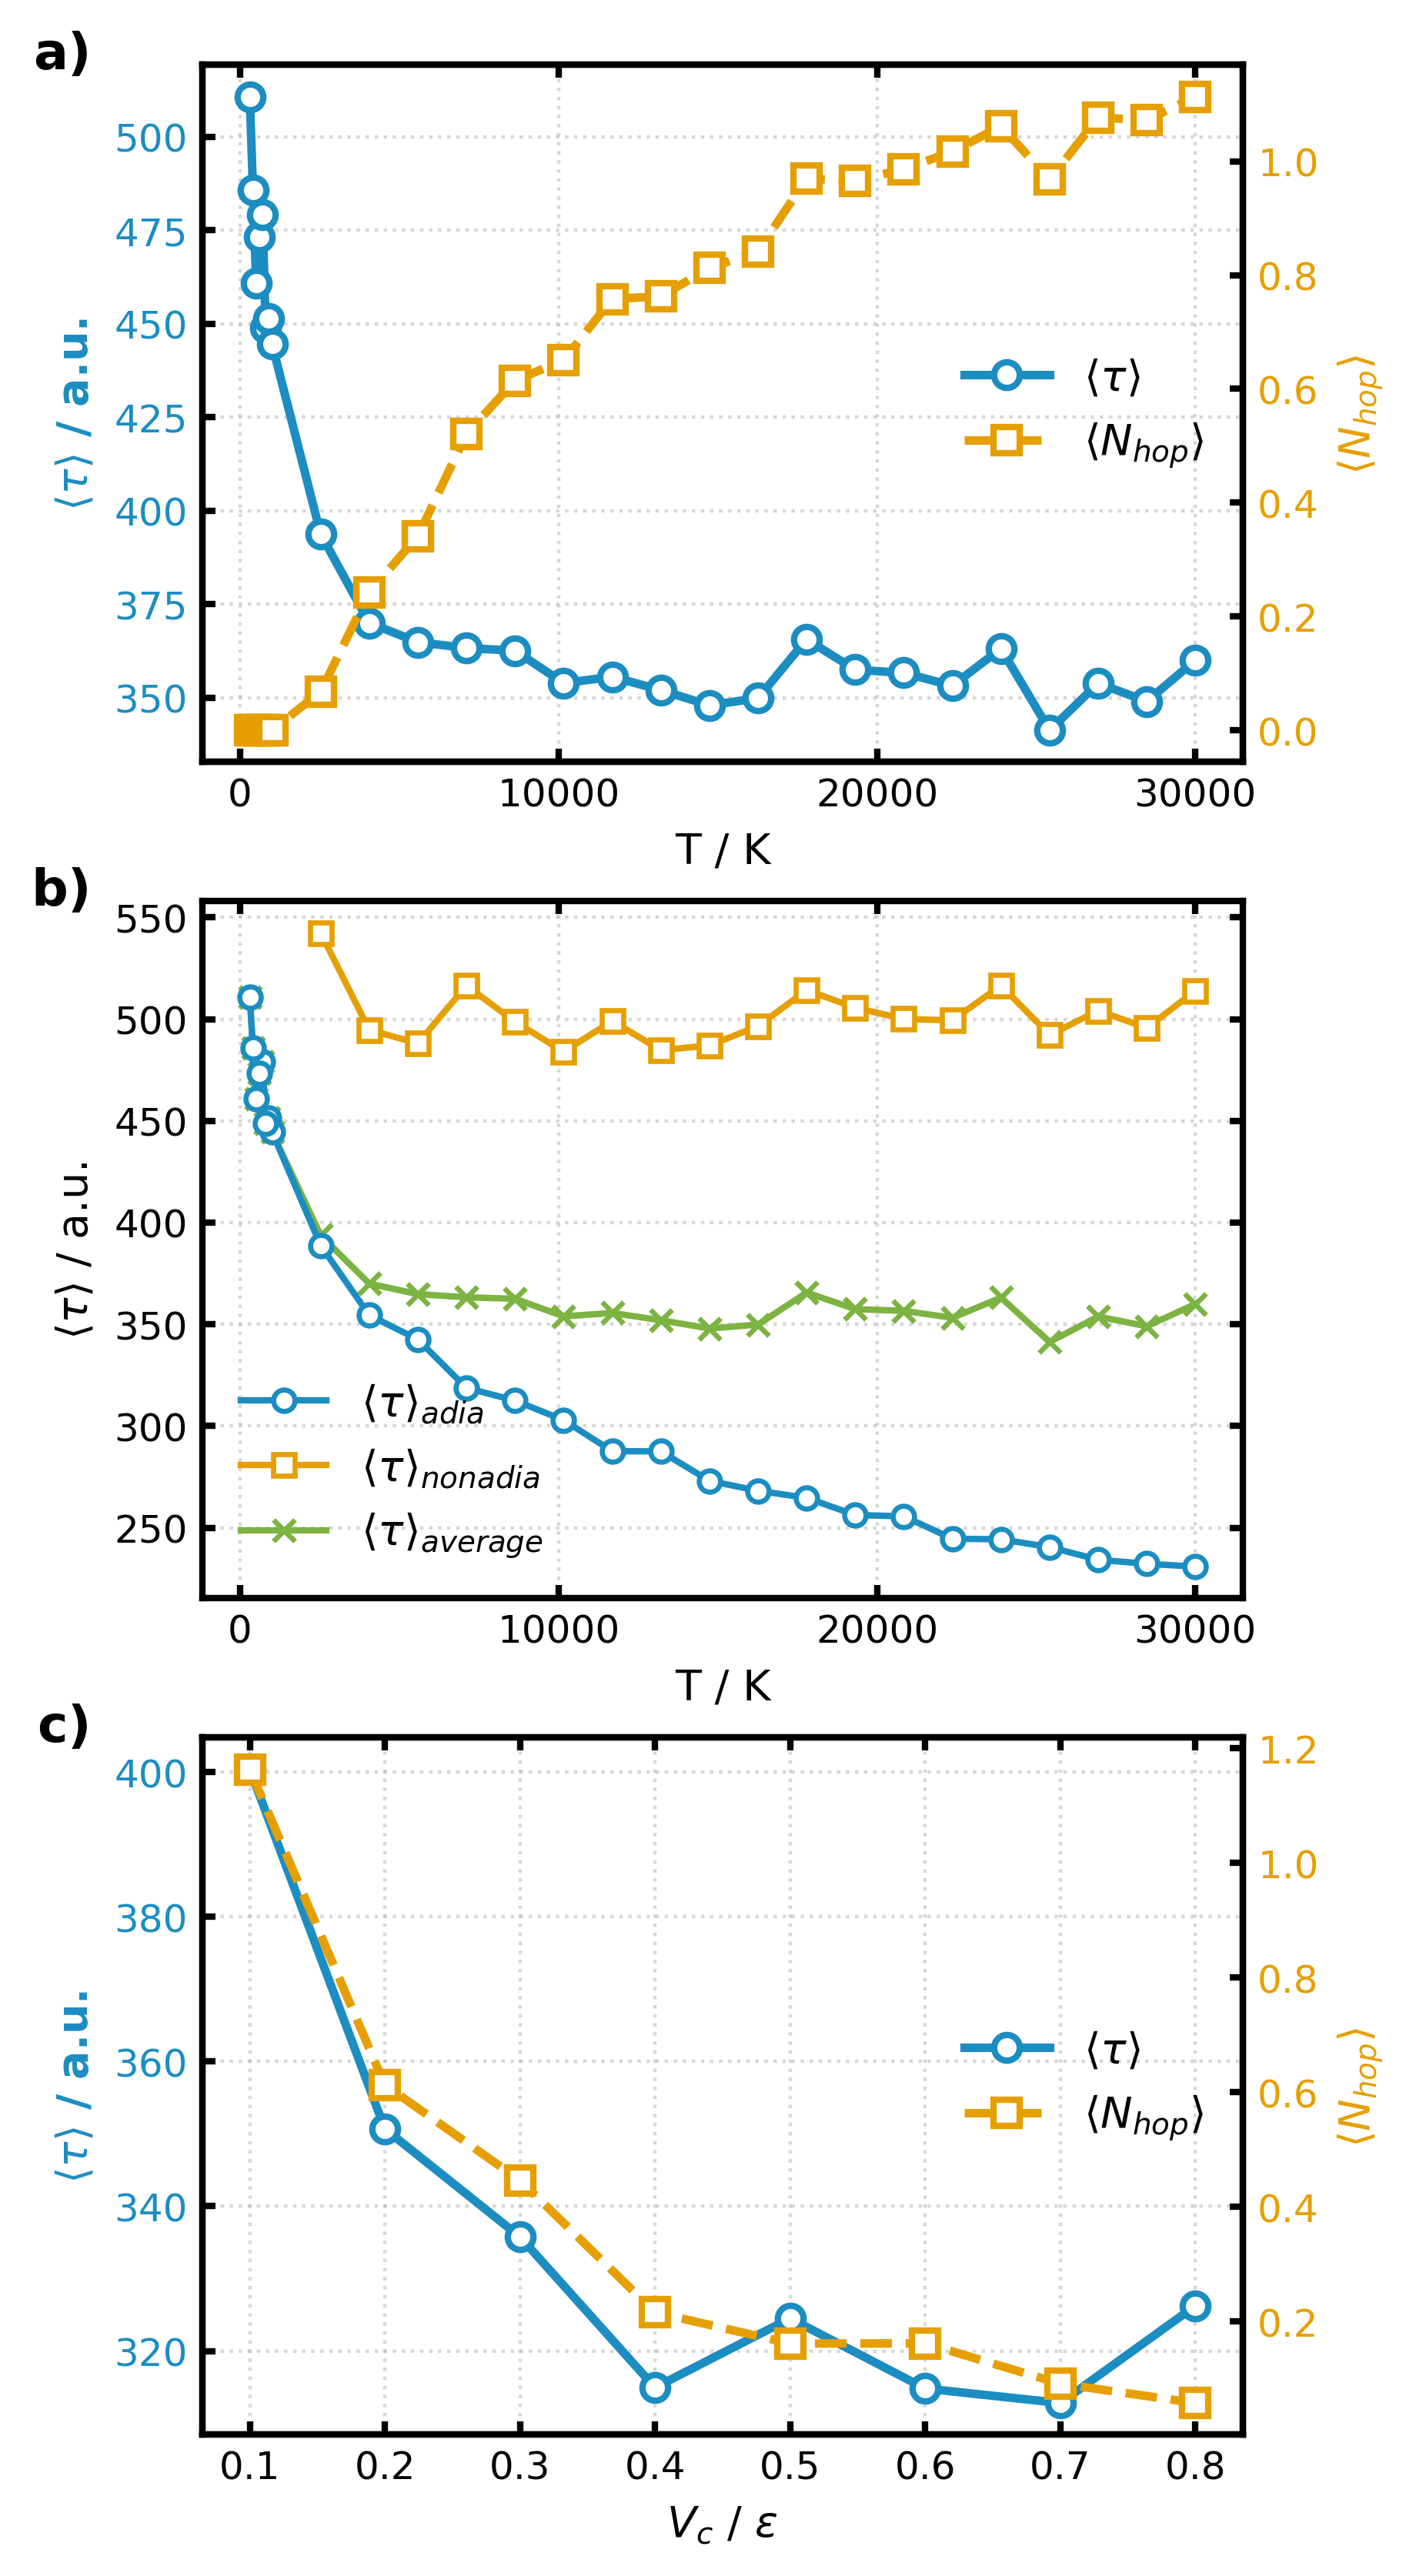

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

with open('Fig4_data.pkl', 'rb') as f:
    Fig4_data = pickle.load(f)

temperature_sweep, mean_total_new, mean_hopful_new, mean_hopless_new, mean_hop_list_new, Vc_v, mean_hop_list_V, mtt_list_V = Fig4_data

# The pristine palette
# winter_pine = "#22403D"
# cranberry   = "#8E2B32"
# golden      = "#BEA07B"
# oxford_blue = "#1B3F6B"


cranberry   = "#E69F00"
golden      = "#7CB342"
oxford_blue  = "#1C8DC1"

palette = [cranberry, golden, oxford_blue]

def remove_off_grid(traj):
    return Trajectory([snap for snap in traj if snap.is_grid])

def plot_combined_kinetics_publish(temperature_sweep, mtt_list, mhpf, mhpl, mean_hop_list, Vc_v, hops_v, mtts_v):
    # ==========================================
    # 1. Aesthetic Setup (Journal Standard)
    # ==========================================
    plt.rcParams.update({
        "figure.figsize": (3.4, 2.6),
        "font.size": 10,                   
        "axes.labelsize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "axes.linewidth": 1.5,            
        "xtick.major.width": 1.5,
        "ytick.major.width": 1.5,
        "xtick.minor.width": 1.0,
        "ytick.minor.width": 1.0,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 2,
        "ytick.minor.size": 2,
    })

    # Sort the arrays to guarantee strict left-to-right line drawing
    temps = np.array(temperature_sweep)
    sort_idx = np.argsort(temps)
    temps = temps[sort_idx]
    mtts = np.array(mtt_list)[sort_idx]
    hops = np.array(mean_hop_list)[sort_idx]
    mhpl_internal = np.array(mhpl)[sort_idx]
    mhpf_internal = np.array(mhpf)[sort_idx]

    # Create a 1x2 double-column figure (7.2 inches wide)
    fig, axes = plt.subplots(3, 1, figsize=(4.36, 10.0), dpi=400)
    

    ax1 = axes[0]
    ax4 = axes[2]
    ax7 = axes[1]

    # ==========================================
    # PANEL (a): MTT & MNT Overlay
    # ==========================================
    # ax1 = axes[0]
    
    # Left Axis: MTT
    ax1.set_xlabel('T / K', fontweight='medium')
    ax1.set_ylabel(r'$\langle \tau \rangle$ / a.u.', color=oxford_blue, fontweight='bold')
    
    line1 = ax1.plot(temps, mtts, color=oxford_blue, linewidth=2, 
                     linestyle='-', marker='o', markersize=6, markerfacecolor='white', 
                     markeredgewidth=1.5, zorder=3, label=r'$\langle \tau \rangle$')
    
    ax1.tick_params(axis='y', labelcolor=oxford_blue, direction='in')
    ax1.tick_params(axis='x', direction='in', top=True)
    ax1.grid(True, linestyle=':', alpha=0.5, zorder=0)

    # Right Axis: MNT
    ax2 = ax1.twinx()
    ax2.set_ylabel(r'$\langle N_{hop} \rangle$', color=cranberry, fontweight='bold')
    
    line2 = ax2.plot(temps, hops, color=cranberry, linewidth=2, 
                     linestyle='--', marker='s', markersize=6, markerfacecolor='white', 
                     markeredgewidth=1.5, zorder=4, label=r'$\langle N_{hop} \rangle$')
    
    ax2.tick_params(axis='y', labelcolor=cranberry, direction='in')

    # Combine legends into a minimalist box
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right', frameon=False)

    # Ensure right spine is thick for ax2
    for spine in ax2.spines.values():
        spine.set_linewidth(1.5)

    # ==========================================
    # PANEL (b): Standard Deviation
    # ==========================================
    # ax3 = axes[0]
    
    # ax3.plot(temps, stds, color=golden, linewidth=1.5, linestyle='-', 
    #          marker='^', markersize=6, markerfacecolor='white', 
    #          markeredgewidth=1.5, zorder=3)

    # ax3.set_xlabel("Temperature / K", fontweight='medium')
    # ax3.set_ylabel(r"$\sigma_\tau$ / a.u.", fontweight='medium')
    
    # ax3.tick_params(direction='in', top=True, right=True)
    # ax3.grid(True, linestyle=':', alpha=0.5, zorder=0)

    # 
    # PANEL (c): MTT & MNT Overlay for V
    #

    # ax4 = axes[1]
    
    # Left Axis: MTT
    ax4.set_xlabel(r"$V_c$ / $\epsilon$", fontweight='medium')
    ax4.set_ylabel(r'$\langle \tau \rangle$ / a.u.', color=oxford_blue, fontweight='bold')
    
    line1 = ax4.plot(Vc_v, mtts_v, color=oxford_blue, linewidth=2, 
                     linestyle='-', marker='o', markersize=6, markerfacecolor='white', 
                     markeredgewidth=1.5, zorder=3, label=r'$\langle \tau \rangle$')
    
    ax4.tick_params(axis='y', labelcolor=oxford_blue, direction='in')
    ax4.tick_params(axis='x', direction='in', top=True)
    ax4.grid(True, linestyle=':', alpha=0.5, zorder=0)

    # Right Axis: MNT
    ax5 = ax4.twinx()
    ax5.set_ylabel(r'$\langle N_{hop} \rangle$', color=cranberry, fontweight='bold')
    
    line2 = ax5.plot(Vc_v, hops_v, color=cranberry, linewidth=2, 
                     linestyle='--', marker='s', markersize=6, markerfacecolor='white', 
                     markeredgewidth=1.5, zorder=4, label=r'$\langle N_{hop} \rangle$')
    
    ax5.tick_params(axis='y', labelcolor=cranberry, direction='in')

    # Combine legends into a minimalist box
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax5.legend(lines, labels, loc='center right', frameon=False)

    # Ensure right spine is thick for ax2
    for spine in ax5.spines.values():
        spine.set_linewidth(1.5)
    
    #
    # PANEL (d) Standard deviation
    #

    # ax6 = axes[1][1]
    
    # ax6.plot(Vc_v, stds_v, color=golden, linewidth=1.5, linestyle='-', 
    #          marker='^', markersize=6, markerfacecolor='white', 
    #          markeredgewidth=1.5, zorder=3)

    # ax6.set_xlabel(r"Non-adiabatic coupling $V_c$($\epsilon$)", fontweight='medium')
    # ax6.set_ylabel(r"$\sigma_\tau$ / a.u.", fontweight='medium')
    
    # ax6.tick_params(direction='in', top=True, right=True)
    # ax6.grid(True, linestyle=':', alpha=0.5, zorder=0)

    #
    # Kinetic bifurcation plot
    #

    temps = temperature_sweep
    
    #
    # Kinetic bifurcation graph
    #

    # ax7 = axes[2]

    ax7.plot(temps, mhpl_internal[::-1], color=oxford_blue, linewidth=1.5, marker='o', 
            markersize=5, markerfacecolor='white', markeredgewidth=1.2, zorder=3,
            label=r'$\langle\tau\rangle_{adia}$')

    # Hop-ful line (Cranberry)
    ax7.plot(temps, np.array(mhpf_internal)[::-1], color=cranberry, linewidth=1.5, marker='s', 
            markersize=5, markerfacecolor='white', markeredgewidth=1.2, zorder=4,
            label=r'$\langle\tau\rangle_{nonadia}$')

    # Reference total MTT (Winter Pine)
    ax7.plot(temps, np.array(mtts)[::-1], color=golden, linewidth=1.5, marker='x', 
            markersize=5, markeredgewidth=1.2, zorder=2,
            label=r'$\langle\tau\rangle_{average}$')
    
    # ==========================================
    # 3. LABELS & FORMATTING
    # ==========================================
    # Clean, journal-style axis labels
    ax7.set_xlabel("T / K", fontweight='medium')
    ax7.set_ylabel(r"$\langle \tau \rangle$ / a.u.", fontweight='medium')
    
    # Grid and Ticks
    ax7.grid(True, linestyle=':', alpha=0.5, zorder=0)
    ax7.tick_params(direction='in', top=True, right=True)
    
    # Thicken axes
    for spine in ax7.spines.values():
        spine.set_linewidth(1.5)
        
    # Legend - no frame, compact
    ax7.legend(loc='best', frameon=False)
    

    # ==========================================
    # FINAL POLISH & EXPORT
    # ==========================================
    # Add publication-style panel letters
    ax1.text(-0.11, 1.05, r"$\mathbf{a)}$", transform=ax1.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
    # ax3.text(-0.15, 1.05, 'b)', transform=ax3.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
    ax4.text(-0.11, 1.05, r"$\mathbf{c)}$", transform=ax4.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
    # ax6.text(-0.15, 1.05, 'd)', transform=ax6.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')
    ax7.text(-0.11, 1.05, r"$\mathbf{b)}$", transform=ax7.transAxes, fontsize=12, fontweight='bold', va='top', ha='right')

    ax1.set_xticks([0, 10000, 20000, 30000])
    ax7.set_xticks([0, 10000, 20000 ,30000])

    # plt.tight_layout()
    plt.show()

# Run the plot:
Vc_v = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8]
plot_combined_kinetics_publish(temperature_sweep=temperature_sweep, mtt_list=mean_total_new, mhpf=mean_hopful_new, mhpl=mean_hopless_new,
                               mean_hop_list=mean_hop_list_new, Vc_v=Vc_v, hops_v=mean_hop_list_V, mtts_v=mtt_list_V)